# Eigenfaces: Face Compression and Recognition

**Team 01 | Mathematics Project | PCA from Scratch with NumPy**

## Project Overview

Can a 64 × 64 face image be represented by only $k$ numbers while retaining enough information for reconstruction and identity recognition? This is the central question in the supplied *Math-Project-Kickoff* brief. This notebook explores it using the Olivetti Faces dataset and principal component analysis (PCA).

Each image contains 4,096 pixel values. PCA learns a shared set of directions of variation from the training faces, called **eigenfaces**. A face can then be described by its coordinates along a smaller number of these directions. These coordinates support both image reconstruction and nearest-neighbor recognition.

### Team 01 Focus: Compression and Reconstruction

Our main question is: **How many components are needed to reconstruct a face with acceptable quality?** The working hypothesis is that reconstruction error decreases as more components are retained, but the benefit of each additional component eventually becomes small. We investigate $k \in \{1,5,10,20,50,100,150,250\}$ using mean squared error, cumulative explained variance, and visual comparisons. The elbow method provides a candidate compromise between representation size and reconstruction quality.

The recognition experiments extend this analysis by asking whether a representation that reconstructs faces well also preserves information useful for identifying people. The number of PCA components and the number of KNN neighbors are separate parameters.

### Notebook Roadmap

1. Prepare the dataset and split images by identity.
2. Compute the training mean face and center the data.
3. Build and sort the PCA eigenface basis.
4. Measure reconstruction error and explained variance.
5. Compare reconstructed faces visually.
6. Investigate component counts with the elbow and silhouette methods.
7. Implement KNN recognition in PCA space.
8. Compare evaluation metrics across parameter settings.

### Implementation and Reproducibility

The PCA transformations and KNN classifier are implemented explicitly with NumPy. Matplotlib displays the figures, pandas formats the result tables, and scikit-learn loads the dataset and calculates the current classification metrics. The split uses seed 42. Run the notebook from the first cell to the last so that every experiment uses the same split, training mean, and sorted eigenvectors.

**Source:** *Math-Project-Kickoff.pdf*, supplied project brief, especially pages 2–5 for the common workflow and pages 6–7 for Team 01's experiment. Its project requirements provide context; the explanations below describe what the current code actually performs.


## 1. Dataset and Experimental Setup

### 1.1 Loading the Libraries

NumPy handles matrix operations and the custom algorithms. The dataset loader supplies images and identity labels, Matplotlib creates plots, and pandas organizes the final evaluation tables.


In [33]:
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
import matplotlib.pyplot as plt
import pandas as pd

### 1.2 Olivetti Faces and the Per-Identity Split

The dataset contains 400 grayscale images of 40 people, with 10 images per person. Each 64 × 64 image becomes a vector of 4,096 pixel intensities; its label identifies the person.

Before learning any parameters, the code shuffles each person's image indices with seed 42 and assigns eight images to training and two to testing. This produces 320 training images and 80 test images, with every identity represented in both sets. The test set measures recognition of new images of these same people.


In [34]:
olivetti_faces = fetch_olivetti_faces()
X = olivetti_faces.data      
y = olivetti_faces.target     

images = olivetti_faces.images 


print("Data shape:", X.shape)
print("Labels shape:", y.shape)
print("Images shape:", images.shape)


X_train = []
y_train = []

X_test = []
y_test = []

rng = np.random.default_rng(seed=42)

for person_id in np.unique(y):

    person_images = np.where(y == person_id)[0]

    person_images = rng.permutation(person_images)

    train_indices = person_images[:8]
    test_indices = person_images[8:]

    X_train.extend(X[train_indices])
    y_train.extend(y[train_indices])

    X_test.extend(X[test_indices])
    y_test.extend(y[test_indices])

X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)

print("-------------------------")

print("Training data:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing data:", X_test.shape)
print("Testing labels:", y_test.shape)

Data shape: (400, 4096)
Labels shape: (400,)
Images shape: (400, 64, 64)
-------------------------
Training data: (320, 4096)
Training labels: (320,)
Testing data: (80, 4096)
Testing labels: (80,)


## 2. Mean Face and Data Centering

### 2.1 Computing the Training Mean

The mean face is the pixel-wise average of the training images:

$$\mu=\frac{1}{N}\sum_{i=1}^{N}x_i, \qquad N=320.$$

It summarizes the average appearance in the training set. Its shape remains `(4096,)`, so the same mean can be subtracted from every image vector.


In [35]:
mean_face = np.mean(X_train, axis=0)

print("Mean vector shape:", mean_face.shape)
print(mean_face)

Mean vector shape: (4096,)
[0.3989281  0.4320894  0.47266275 ... 0.31893095 0.31306827 0.31074393]


### 2.2 Displaying the Mean Face

Reshaping the mean vector to 64 × 64 makes the average face visible. Fine details may appear blurred because expressions, lighting, and facial features vary across the training images.


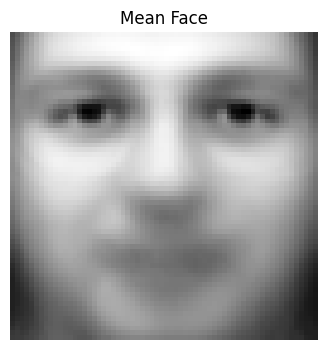

In [36]:
mean_face_image = mean_face.reshape(64,64)

plt.figure(figsize=(4,4))

plt.imshow(mean_face_image, cmap="gray")

plt.title("Mean Face")

plt.axis("off")

plt.show()

### 2.3 Visualizing a Centered Face

Subtracting the training mean gives $x_c=x-\mu$. Positive and negative values describe how a pixel differs from the average face. The figure compares an original training image with this difference image; the centered image is a mathematical representation rather than an ordinary photograph.


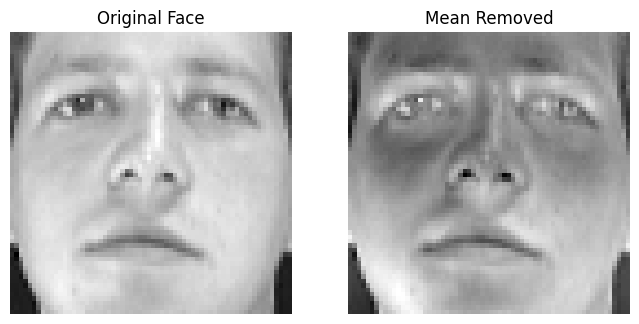

In [37]:
face = X_train[1]

centered_face = face - mean_face

original_image = face.reshape(64,64)

centered_image = centered_face.reshape(64,64)


plt.figure(figsize=(8,4))


plt.subplot(1,2,1)
plt.imshow(original_image,cmap="gray")
plt.title("Original Face")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(centered_image,cmap="gray")
plt.title("Mean Removed")
plt.axis("off")


plt.show()

### 2.4 Why Centering Leaves Variance Unchanged

The complete centered training matrix is $X_c=X_{\mathrm{train}}-\mu$. Each pixel column now has a mean close to zero. Subtracting a constant shifts a column without changing its spread, so its variance before and after centering should be equal up to numerical precision. Equal printed variances are therefore expected.


In [38]:

var_before = np.var(X_train, axis=0)
mean_face = np.mean(X_train, axis=0)
X_train_centered = X_train - mean_face
var_after = np.var(X_train_centered, axis=0)


print("Average variance before:")
print(np.mean(var_before))


print("Average variance after:")
print(np.mean(var_after))

Average variance before:
0.019328536
Average variance after:
0.019328536


## 3. Learning the Eigenface Basis

### 3.1 Covariance and Eigendecomposition

The sample covariance matrix describes how pixel intensities vary together:

$$C=\frac{X_c^TX_c}{N-1}.$$

Here $C$ has shape 4096 × 4096. `np.linalg.eigh` finds eigenvalues and orthonormal eigenvectors of this symmetric matrix. An eigenvalue measures the variance along its corresponding eigenvector; reshaping an eigenvector into image form gives an eigenface. With 320 centered training samples, at most 319 directions can have nonzero variance in exact arithmetic.


In [39]:
N = X_train_centered.shape[0]

cov_matrix = (X_train_centered.T @ X_train_centered) / (N - 1)

print("Covariance shape:", cov_matrix.shape)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Covariance shape: (4096, 4096)
Eigenvalues shape: (4096,)
Eigenvectors shape: (4096, 4096)


### 3.2 Sorting Components by Importance

`np.linalg.eigh` returns eigenvalues in ascending order. PCA needs the highest-variance directions first, so we reverse their order and apply the identical reordering to the eigenvector columns.

All later projections and reconstructions use `eigenvectors_sorted[:, :k]`. Taking the first columns of the unsorted matrix would select low-variance directions and discard the useful leading components.


In [40]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]


print(eigenvalues_sorted[:10])

[18.929564  11.67412    6.135419   3.816551   2.825244   2.5447426
  1.913367   1.6314561  1.6081694  1.3030156]


## 4. Reconstruction Error and Explained Variance

### 4.1 Measuring Reconstruction with Mean Squared Error

Let $U_k$ contain the first $k$ columns of the sorted eigenvector matrix. Projection gives a compact representation $Z$, and reconstruction maps it back into pixel space:

$$Z=(X-\mu)U_k, \qquad \widehat X=ZU_k^T+\mu.$$

The reconstruction error is the mean squared difference over all images and pixels:

$$\mathrm{MSE}=\frac{1}{nd}\sum_{i=1}^{n}\sum_{j=1}^{d}(X_{ij}-\widehat X_{ij})^2, \qquad d=4096.$$

Lower MSE means better pixel-level reconstruction. It does not directly measure identity recognition. The experiments below pass **training images** to this function, so their errors describe how well the learned subspace represents the training set.


In [41]:
def reconstruction_error(X_data, mean_face, eigenvectors, k):

    U_k = eigenvectors[:, :k]
    Z = (X_data - mean_face) @ U_k
    X_reconstructed = Z @ U_k.T + mean_face 
    mse = np.mean((X_data - X_reconstructed) ** 2)

    return mse


### 4.2 Comparing the Team 01 Component Counts

We compute training reconstruction MSE for $k=1,5,10,20,50,100,150,250$. Small representations retain the broadest variations; larger ones can recover finer details. The error values provide a numerical counterpart to the visual reconstruction comparison.


In [42]:
k_values = [1, 5, 10, 20, 50, 100, 150, 250]

errors = []

for k in k_values:
    error = reconstruction_error(
        X_train,
        mean_face,
        eigenvectors_sorted,
        k
    )
    errors.append(error)

errors


[np.float32(0.014721503),
 np.float32(0.008770593),
 np.float32(0.0065800115),
 np.float32(0.0045058974),
 np.float32(0.0023486516),
 np.float32(0.0011158648),
 np.float32(0.00056735927),
 np.float32(0.00010805777)]

### 4.3 Interpreting the Error and Variance Curves

The error curve shows the information lost when only the first $k$ components are retained. With a fixed, orthonormal PCA basis, adding components cannot increase reconstruction MSE, apart from numerical roundoff.

For eigenvalues sorted from largest to smallest, cumulative explained variance is

$$V(k)=\frac{\sum_{j=1}^{k}\lambda_j}{\sum_{j=1}^{d}\lambda_j}.$$

The plots mark the first component counts that reach 90%, 95%, and 99% of training variance. The full view shows the overall spectrum; the zoomed view makes the threshold crossings easier to read. These thresholds describe retained variance, so 95% explained variance does **not** imply 95% recognition accuracy.


In [43]:
def plot_pca_results(k_values, errors, eigenvalues, thresholds=[0.90, 0.95, 0.99]):

    plt.figure(figsize=(8,5))
    plt.plot(k_values, errors, marker='o')

    plt.xlabel("Number of Components (k)")
    plt.ylabel("Reconstruction Error (MSE)")
    plt.title("Reconstruction Error vs k")
    plt.grid()
    plt.show()


    cumulative_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)

    threshold_ks = []

    for threshold in thresholds:
        k = np.argmax(cumulative_variance >= threshold) + 1
        threshold_ks.append(k)

    plt.figure(figsize=(10,6))

    plt.plot(
        range(1, len(cumulative_variance)+1),
        cumulative_variance
    )

    for threshold in thresholds:

        k = np.argmax(cumulative_variance >= threshold) + 1

        plt.axhline(y=threshold, linestyle="--")
        plt.axvline(x=k, linestyle="--")
        plt.scatter(k, threshold, s=60)

    plt.xlabel("Number of Components (k)")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("Cumulative Variance - Full View")
    plt.grid()
    plt.show()


    x_max = min(max(threshold_ks) + 40, len(cumulative_variance))

    plt.figure(figsize=(10,6))

    plt.plot(
        range(1, len(cumulative_variance)+1),
        cumulative_variance
    )

    for i, threshold in enumerate(thresholds):

        k = np.argmax(cumulative_variance >= threshold) + 1

        plt.axhline(y=threshold, linestyle="--")
        plt.axvline(x=k, linestyle="--")
        plt.scatter(k, threshold, s=60)

        plt.text(
            k + 5,
            threshold - 0.02*i,
            f"threshold={threshold:.2f}, k={k}",
            fontsize=10
        )

    plt.xlim(0, x_max)
    plt.ylim(min(thresholds) - 0.05, 1.02)

    plt.xlabel("Number of Components (k)")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("Cumulative Variance - Zoomed View")
    plt.grid()
    plt.show()

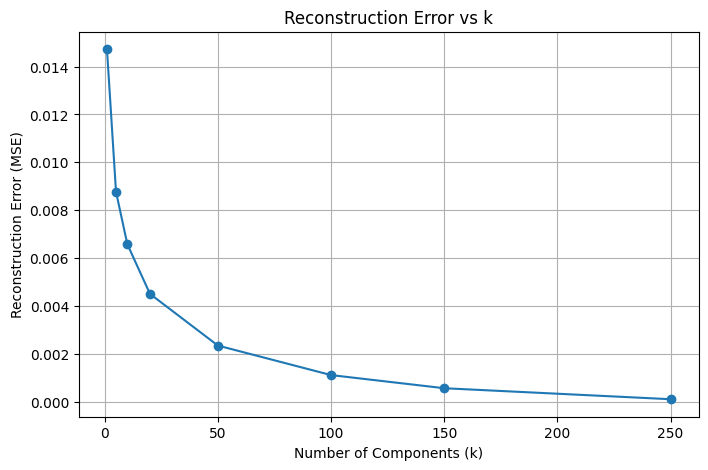

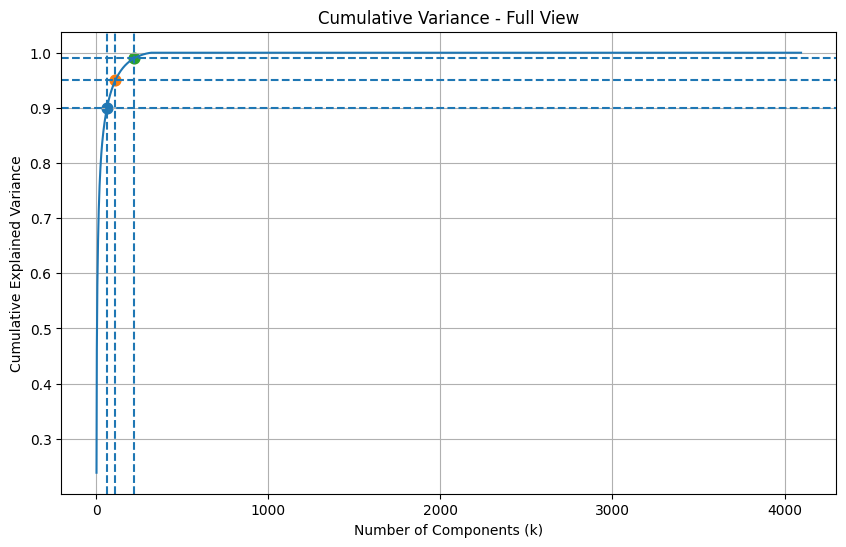

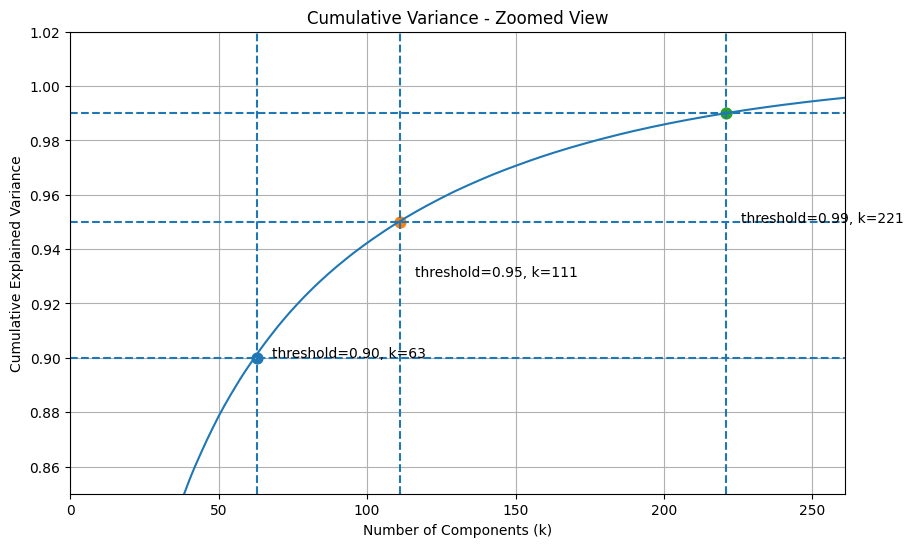

In [44]:
plot_pca_results(
    k_values,
    errors,
    eigenvalues_sorted
)


## 5. Visual Comparison of Reconstructed Faces

### 5.1 Reconstructing One Image

The function below compresses one image into $k$ coefficients, combines the corresponding eigenfaces, and restores the mean face. The resulting vector has 4,096 values and can be reshaped into an image.

The ratio $4096/k$ describes the reduction in the number of per-image coefficients. It is not a complete file-compression ratio: reconstruction also requires storing the shared mean and eigenface basis.


In [45]:
def reconstruct_image(image, mean_face, eigenvectors, k):
    U_k = eigenvectors[:, :k]
    z = (image - mean_face) @ U_k
    reconstructed = z @ U_k.T + mean_face
    return reconstructed


### 5.2 Arranging Original and Reconstructed Images

Each row presents a selected person's original training image followed by reconstructions at different component counts. This makes it easier to compare facial structure and detail within the same face.


In [46]:
def show_reconstructions_by_k(images, mean_face, eigenvectors, k_values, labels, samples_per_person=1):
    selected_images = []
    selected_labels = []

    for person in np.unique(labels):
        indices = np.where(labels == person)[0][:samples_per_person]
        selected_images.extend(indices)
        selected_labels.extend(labels[indices])
        if len(selected_labels) >= 4:
            break

    plt.figure(figsize=(3 * (len(k_values) + 1), 3 * len(selected_images)))

    plot_index = 1

    for idx in selected_images:
        original = images[idx]

        plt.subplot(len(selected_images), len(k_values) + 1, plot_index)
        plt.imshow(original.reshape(64,64), cmap="gray")
        plt.title("Original")
        plt.axis("off")
        plot_index += 1

        for k in k_values:
            reconstructed = reconstruct_image(
                original,
                mean_face,
                eigenvectors,
                k
            )

            plt.subplot(len(selected_images), len(k_values) + 1, plot_index)
            plt.imshow(reconstructed.reshape(64,64), cmap="gray")
            plt.title(f"k={k}")
            plt.axis("off")
            plot_index += 1

    plt.tight_layout()
    plt.show()


### 5.3 Comparing 10, 50, 100, and 150 Components

The grid includes the brief's requested values of 10, 50, and 150 components, plus 100 as an intermediate point. Look for changes in face outline, eyes, mouth, and fine texture. Compare these impressions with MSE before deciding whether extra components offer a useful improvement. These examples come from the training set.


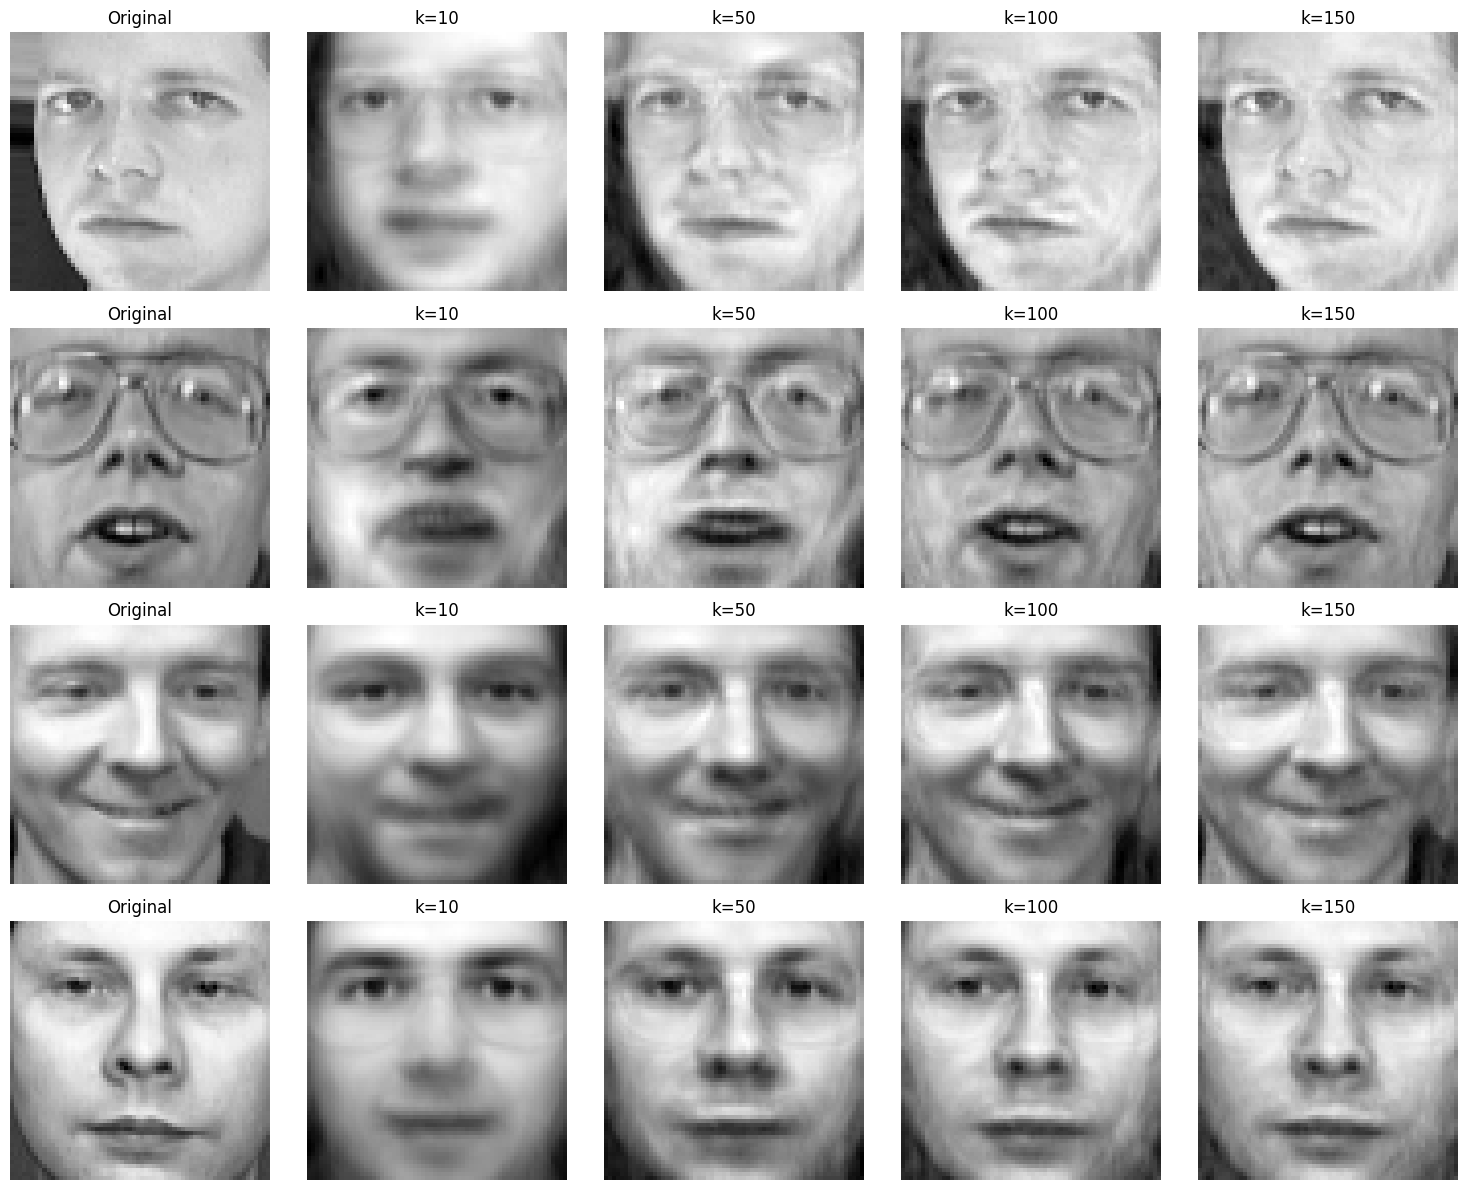

In [47]:
k_values = [10, 50, 100, 150]

show_reconstructions_by_k(
    X_train,
    mean_face,
    eigenvectors_sorted,
    k_values,
    y_train
)


### 5.4 Optional Explained-Variance Plot Helper

This cell defines an alternative compact plot of cumulative explained variance. Defining the function does not display a new figure; the earlier component-analysis section already produces variance plots.


In [48]:
def plot_cumulative_variance(eigenvalues, thresholds=[0.9, 0.95, 0.99]):

    cumulative_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)

    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance)

    for t in thresholds:
        k = np.argmax(cumulative_variance >= t) + 1

        plt.axhline(t, linestyle="--")
        plt.axvline(k, linestyle="--")
        plt.scatter(k, t)
        plt.text(k, t, f"k={k}, {t*100}%")

    plt.xlabel("Number of Components (k)")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("Cumulative Explained Variance")
    plt.grid()
    plt.show()


## 6. Investigating the Number of Components

### 6.1 Preparing the Reconstruction Curve

We rebuild the error list using the full Team 01 component grid. This ensures that each error supplied to the elbow method corresponds to the correct component count, even though later visualization cells use a shorter list of values.


In [49]:
k_values_error = [1,5,10,20,50,100,150,250]

errors = []

for k in k_values_error:

    error = reconstruction_error(
        X_train,
        mean_face,
        eigenvectors_sorted,
        k
    )

    errors.append(error)


### 6.2 Choosing a Candidate with the Elbow Method

The elbow method searches for a point where the reconstruction-error curve begins to flatten. This implementation joins the first and last sampled points with a straight line and selects the point farthest from that line.

The returned $k$ is a candidate among the tested values, not a guaranteed optimum. Its value depends on the sampled component counts and the scale of the plotted axes. For Team 01, it should be interpreted together with the reconstructed images and explained-variance curve.


In [50]:
def elbow_method(k_values, errors):

    k_values = np.array(k_values)
    errors = np.array(errors)

    points = np.column_stack(
        (k_values, errors)
    )

    start = points[0]
    end = points[-1]

    distances = []

    for point in points:

        distance = np.abs(
            np.cross(
                end-start,
                start-point
            )
        ) / np.linalg.norm(end-start)

        distances.append(distance)


    best_index = np.argmax(distances)
    best_k = k_values[best_index]


    plt.figure(figsize=(8,5))

    plt.plot(
        k_values,
        errors,
        marker="o"
    )

    plt.scatter(
        best_k,
        errors[best_index],
        s=100
    )

    plt.axvline(
        best_k,
        linestyle="--"
    )

    plt.text(
        best_k,
        errors[best_index],
        f"  Elbow k={best_k}"
    )


    plt.xlabel("Number of Components (k)")
    plt.ylabel("Reconstruction Error (MSE)")
    plt.title("Elbow Method")

    plt.grid()
    plt.show()


    return best_k

#### Applying the Elbow Criterion

The next cell displays the selected point on the error curve and stores it as `best_k_elbow`. Treat it as a reconstruction-based candidate supported by the training data; recognition quality is examined separately.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_32976\3850838988.py:18: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  np.cross(


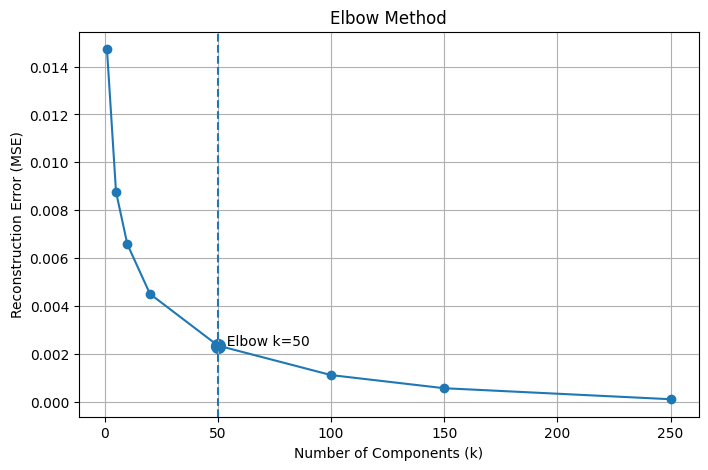

Best k by Elbow: 50


In [51]:
best_k_elbow = elbow_method(
    k_values_error,
    errors
)

print("Best k by Elbow:", best_k_elbow)


### 6.3 Measuring Identity Separation with Silhouette Scores

This additional experiment uses the known **training identity labels** to assess separation in PCA space. It does not run a clustering algorithm. For each projected face, $a(i)$ is its average distance to other training faces of the same person, and $b(i)$ is the smallest average distance to a different person's group:

$$s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}.$$

Scores near 1 indicate well-separated groups; scores near 0 indicate overlap, and negative values suggest a face is closer on average to another identity's group. The selected $k$ maximizes the mean score among the tested values. This measures class geometry and need not select the same component count as reconstruction error or KNN accuracy.


In [52]:
def silhouette_method(X, y, mean_face, eigenvectors, k_values):

    scores = []

    for k in k_values:

        U_k = eigenvectors[:, :k]

        X_projected = (X - mean_face) @ U_k

        sample_scores = []

        for i in range(len(X_projected)):

            same_class = y == y[i]
            same_class[i] = False

            a = np.mean(
                np.linalg.norm(
                    X_projected[same_class] - X_projected[i],
                    axis=1
                )
            )

            b_values = []

            for label in np.unique(y):

                if label != y[i]:

                    other = y == label

                    b_values.append(
                        np.mean(
                            np.linalg.norm(
                                X_projected[other] - X_projected[i],
                                axis=1
                            )
                        )
                    )

            b = min(b_values)

            sample_scores.append(
                (b-a) / max(a,b)
            )

        scores.append(np.mean(sample_scores))

    return scores


#### Comparing Silhouette Scores Across Component Counts

The experiment evaluates $k=10,20,50,100,150,200$ and stores the highest-scoring choice as `best_k_silhouette`. A flatter curve means the tested representations have similar separation under this distance-based criterion.


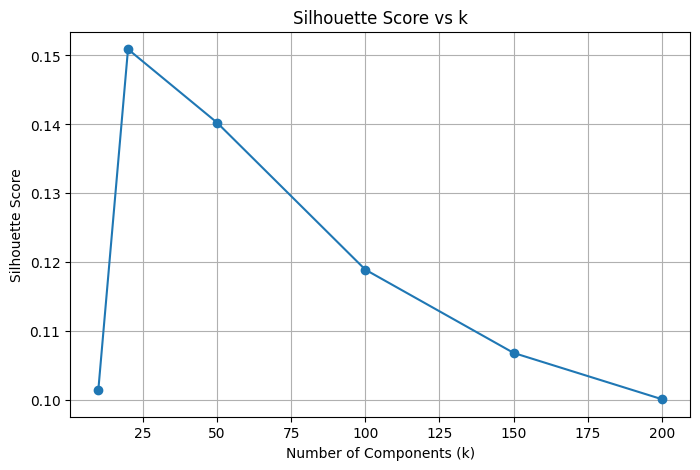

Best k by Silhouette: 20


In [53]:
k_values_silhouette = [10,20,50,100,150,200]

silhouette_scores = silhouette_method(
    X_train,
    y_train,
    mean_face,
    eigenvectors_sorted,
    k_values_silhouette
)

plt.figure(figsize=(8,5))

plt.plot(
    k_values_silhouette,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Components (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.grid()

plt.show()


best_k_silhouette = k_values_silhouette[
    np.argmax(silhouette_scores)
]

print("Best k by Silhouette:", best_k_silhouette)


## 7. Face Recognition with KNN in PCA Space

After learning the PCA basis, each training and test image is represented by $k$ coordinates. K-nearest neighbors (KNN) predicts a test face's identity from the labels of nearby training faces.

- **PCA components ($k$):** the number of coordinates used to represent a face.
- **KNN neighbors (`n_neighbors`):** the number of training faces participating in the vote.

With one neighbor, the prediction is the identity of the closest training image. With multiple neighbors, the prediction uses a majority vote. All recognition experiments use test images as queries and training images as the reference set.

### 7.1 Projecting Training and Test Faces Consistently

Both sets must use the **same training mean and the same sorted eigenvectors**. Recomputing a mean or a basis on the test set would change the representation and use information that should remain held out. The function below returns an $n\times k$ matrix of PCA coordinates.


In [54]:
def project_to_pca(X, mean_face, eigenvectors, k):

    U_k = eigenvectors[:, :k]

    X_projected = (X - mean_face) @ U_k

    return X_projected


### 7.2 Implementing Nearest-Neighbor Voting

For each test vector, the classifier calculates Euclidean distances to all training vectors, selects the nearest `n_neighbors` samples, and counts their labels. It predicts the most frequent identity.

In a tied vote, this implementation chooses the smallest label among the tied classes because `np.unique` sorts labels and `np.argmax` selects the first maximum. An odd neighbor count does not eliminate ties in a 40-class problem. With only eight training images per identity, increasing the neighbor count can also introduce more competing identities.


In [55]:
def knn_predict(X_train, y_train, X_test, n_neighbors=1):

    predictions = []


    for test_sample in X_test:

        distances = np.linalg.norm(
            X_train - test_sample,
            axis=1
        )


        nearest_indices = np.argsort(distances)[:n_neighbors]


        nearest_labels = y_train[nearest_indices]


        labels, counts = np.unique(
            nearest_labels,
            return_counts=True
        )


        prediction = labels[np.argmax(counts)]

        predictions.append(prediction)


    return np.array(predictions)


### 7.3 Defining the Evaluation Metrics

- **Accuracy:** the fraction of test images assigned the correct identity.
- **Precision:** for each predicted identity, the fraction of predictions that are correct.
- **Recall:** for each true identity, the fraction of its test images recognized correctly.
- **F1-score:** the harmonic mean of precision and recall for each identity, followed by weighted averaging.

The function returns fractions between 0 and 1: `0.90` means 90%. Undefined precision or recall contributions are set to zero. For this single-label multiclass task, support-weighted recall equals accuracy, so matching values in those columns are expected.


In [56]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def eval_scores(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    # Olivetti Faces is a multiclass dataset (40 people),
    # so use averaging over all classes.
    precision = precision_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    f1 = f1_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


### 7.4 Baseline: 50 Components and 3 Neighbors

This first recognition experiment projects both datasets onto 50 leading components and predicts the 80 test identities using three neighbors. It provides a reference configuration for the later comparisons.


In [57]:
pca_k = 50
neighbors = 3


X_train_pca = project_to_pca(
    X_train,
    mean_face,
    eigenvectors_sorted,
    pca_k
)


X_test_pca = project_to_pca(
    X_test,
    mean_face,
    eigenvectors_sorted,
    pca_k
)


y_pred = knn_predict(
    X_train_pca,
    y_train,
    X_test_pca,
    neighbors
)


accuracy = accuracy_score(
    y_test,
    y_pred
)


print("PCA k:", pca_k)
print("Neighbors:", neighbors)
print("Accuracy:", accuracy)


PCA k: 50
Neighbors: 3
Accuracy: 0.9


### 7.5 Effect of PCA Components with 3 Neighbors

The number of neighbors stays fixed at three while the component count changes. This isolates the effect of representation size on recognition. Accuracy need not increase monotonically with $k$: the directions that preserve additional pixel variance may not help distinguish people.


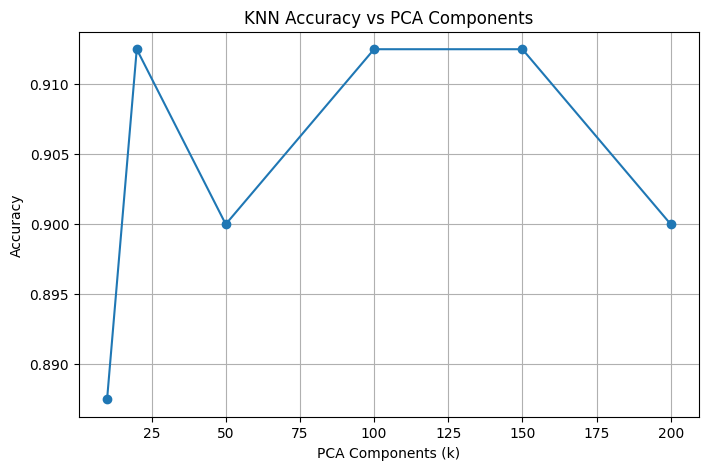

In [58]:
pca_values = [10,20,50,100,150,200]

accuracies = []

for pca_k in pca_values:

    X_train_pca = project_to_pca(
        X_train,
        mean_face,
        eigenvectors_sorted,
        pca_k
    )


    X_test_pca = project_to_pca(
        X_test,
        mean_face,
        eigenvectors_sorted,
        pca_k
    )


    y_pred = knn_predict(
        X_train_pca,
        y_train,
        X_test_pca,
        n_neighbors=3
    )


    accuracies.append(
        accuracy_score(
            y_test,
            y_pred
        )
    )


plt.figure(figsize=(8,5))

plt.plot(
    pca_values,
    accuracies,
    marker="o"
)

plt.xlabel("PCA Components (k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs PCA Components")

plt.grid()
plt.show()


### 7.6 Effect of Neighbor Count with 20 Components

This plot fixes the PCA dimension at 20 and compares 1, 3, 5, 7, and 9 neighbors. A larger neighborhood changes the balance of votes and may include faces from other identities. The later neighbor table uses **100 components**, so its values are not expected to match this plot directly.


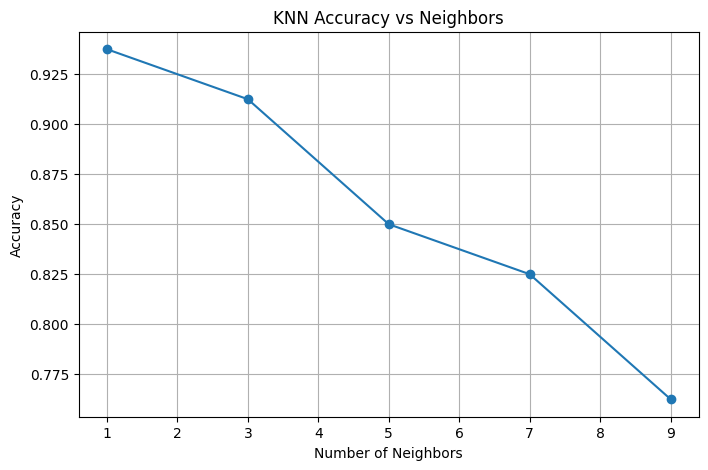

In [59]:
neighbors_values = [1,3,5,7,9]

neighbor_accuracy = []

pca_k = 20


X_train_pca = project_to_pca(
    X_train,
    mean_face,
    eigenvectors_sorted,
    pca_k
)


X_test_pca = project_to_pca(
    X_test,
    mean_face,
    eigenvectors_sorted,
    pca_k
)


for n in neighbors_values:

    y_pred = knn_predict(
        X_train_pca,
        y_train,
        X_test_pca,
        n_neighbors=n
    )


    neighbor_accuracy.append(
        accuracy_score(
            y_test,
            y_pred
        )
    )


plt.figure(figsize=(8,5))

plt.plot(
    neighbors_values,
    neighbor_accuracy,
    marker="o"
)

plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs Neighbors")

plt.grid()
plt.show()


## 8. Classification Metrics and Comparison Tables

The following tables summarize the same test-set recognition procedure for several PCA and KNN settings. Each row describes one configuration, with larger metric values indicating better performance on this split.

### 8.1 Reusing the Evaluation Function

The next cell repeats the metric function used earlier. Precision, recall, and F1 are computed separately for each identity and then averaged using each identity's test support as its weight. There are two test images per person, so these support weights are equal in this experiment.

These are descriptive parameter comparisons. Choosing the highest-scoring row after inspecting the test set would make that set part of model selection. A final parameter choice should instead use a validation split within the training data, fitting the mean and PCA basis on the corresponding training portion.


In [60]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def eval_scores(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    f1 = f1_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


### 8.2 PCA Comparison Table: 3 Neighbors

Each row uses a different component count with three neighbors. Accuracy matches the corresponding point in the PCA comparison plot, while precision, recall, and F1 provide additional views of the classification errors.


In [61]:
results_pca = []

pca_values = [10,20,50,100,150,200]

for pca_k in pca_values:

    X_train_pca = project_to_pca(
        X_train,
        mean_face,
        eigenvectors_sorted,
        pca_k
    )

    X_test_pca = project_to_pca(
        X_test,
        mean_face,
        eigenvectors_sorted,
        pca_k
    )

    y_pred = knn_predict(
        X_train_pca,
        y_train,
        X_test_pca,
        n_neighbors=3
    )

    scores = eval_scores(
        y_test,
        y_pred
    )

    scores["PCA_k"] = pca_k

    results_pca.append(scores)


pca_results_table = pd.DataFrame(results_pca)

pca_results_table


,accuracy,precision,recall,f1,PCA_k
0,0.8875,0.895833,0.8875,0.878333,10
1,0.9125,0.925000,0.9125,0.905000,20
2,0.9000,0.883333,0.9000,0.881667,50
3,0.9125,0.916667,0.9125,0.901667,100
4,0.9125,0.916667,0.9125,0.901667,150
5,0.9000,0.912500,0.9000,0.890000,200


### 8.3 Neighbor Comparison Table: 100 Components

This table holds the representation at 100 components and varies the neighbor count. Comparisons within the table show the effect of voting size under this fixed representation. Its setting differs from the earlier neighbor plot, which uses 20 components.


In [62]:
results_neighbors = []

pca_k = 100

X_train_pca = project_to_pca(
    X_train,
    mean_face,
    eigenvectors_sorted,
    pca_k
)

X_test_pca = project_to_pca(
    X_test,
    mean_face,
    eigenvectors_sorted,
    pca_k
)


neighbors_values = [1,3,5,7,9]


for n in neighbors_values:

    y_pred = knn_predict(
        X_train_pca,
        y_train,
        X_test_pca,
        n_neighbors=n
    )


    scores = eval_scores(
        y_test,
        y_pred
    )

    scores["neighbors"] = n

    results_neighbors.append(scores)


neighbor_results_table = pd.DataFrame(results_neighbors)

neighbor_results_table


,accuracy,precision,recall,f1,neighbors
0,0.9375,0.933333,0.9375,0.927500,1
1,0.9125,0.916667,0.9125,0.901667,3
2,0.8750,0.887500,0.8750,0.864167,5
3,0.8000,0.845000,0.8000,0.784405,7
4,0.8000,0.837976,0.8000,0.783730,9


### 8.4 Combined PCA and KNN Evaluation Table

The final table evaluates all 30 combinations of six component counts and five neighbor counts. Every row uses the same training/test split and the same training-derived PCA basis. Both projections must use `eigenvectors_sorted` so that their first $k$ columns represent the leading principal components.

To isolate one parameter, compare rows that hold the other fixed. Rows with three neighbors should agree with the PCA table; rows with 100 components should agree with the neighbor table. All metric values are fractions, and one additional correct prediction among 80 test images changes accuracy by 0.0125, or 1.25 percentage points.


In [67]:
combined_results = []

pca_values = [10, 20, 50, 100, 150, 200]
neighbors_values = [1, 3, 5, 7, 9]

for pca_k in pca_values:
    X_train_pca = project_to_pca(
        X_train,
        mean_face,
        eigenvectors_sorted,
        pca_k
    )

    X_test_pca = project_to_pca(
        X_test,
        mean_face,
        eigenvectors_sorted,
        pca_k
    )

    for n in neighbors_values:
        y_pred = knn_predict(
            X_train_pca,
            y_train,
            X_test_pca,
            n_neighbors=n
        )

        scores = eval_scores(y_test, y_pred)

        combined_results.append({
            "PCA Components (k)": pca_k,
            "KNN Neighbors": n,
            "Accuracy": scores["accuracy"],
            "Precision": scores["precision"],
            "Recall": scores["recall"],
            "F1-score": scores["f1"]
        })

combined_table = pd.DataFrame(combined_results)

combined_table

,PCA Components (k),KNN Neighbors,Accuracy,Precision,Recall,F1-score
0,10,1,0.9250,0.929167,0.9250,0.913333
1,10,3,0.8875,0.895833,0.8875,0.878333
2,10,5,0.8125,0.825000,0.8125,0.800000
3,10,7,0.7500,0.729167,0.7500,0.715000
4,10,9,0.6625,0.622500,0.6625,0.615119
5,20,1,0.9375,0.945833,0.9375,0.931667
6,20,3,0.9125,0.925000,0.9125,0.905000
7,20,5,0.8500,0.862500,0.8500,0.835000
8,20,7,0.8250,0.850000,0.8250,0.813333
9,20,9,0.7625,0.754167,0.7625,0.730833
